# Shap: Model Interpretation
[SHAP] (SHapley Additive exPlanations) is a game theoretic approach to explain Machine Learning models. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions. All charts in SHAP use Shapley values and feature values since they represent a feature's responsibility for a change in the model output. The SHAP values provide two great advantages come along with 3 main types of charts (bar, waterfall and scatter plot):
- Global interpretability - the SHAP values can show how much each predictor contributes, either positively or negatively, to the target variable. This is like the variable importance plot but it is able to show the positive or negative relationship for each variable with the target
- Local interpretability - each observation gets its own set of SHAP values. Traditional variable importance algorithms only show the results across the entire population but not on each individual case. The local interpretability enables us to pinpoint and contrast the impacts of the factors

SHAP has a total of 5 explainers out of which 2 are frequently used: *tree explainer* and *kernel explainer*. Others is using for text, image and deep learning. The difference between these explainers is the algorithm used to compute the SHAP values. But there is 1 module called *Explainer* - it can be used with any model but taking long time to print the result. To optimize the speed, use the right explainer with the model. There are two documentation sites can be found, the [official one] with mainly of notebook examples and an [non-official one] with API references.

[SHAP]: https://github.com/slundberg/shap
[official one]: https://shap.readthedocs.io/en/latest/index.html
[non-official one]: https://shap-lrjball.readthedocs.io/en/latest/index.html

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LogisticRegression

import torch
import transformers

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")
np.set_printoptions(precision=8, suppress=True)
shap.initjs()
%config InlineBackend.figure_format = 'retina'

## 1. Tree visualization

In [ ]:
from dshub import np, pd, plt, sns, ml, stats
import dtreeviz

## 2. Tabular explainers

In [ ]:
from dshub import np, pd, plt, sns, ml, stats

import shap
shap.initjs()

In [115]:
df_boston = pd.read_csv('../data/boston.csv')
x_boston = df_boston.drop(columns='price')
y_boston = df_boston['price']

reg = ml.XGBoostRegressor()
reg = reg.fit(x_boston, y_boston)

In [26]:
df_cancer = pd.read_csv('../data/breast_cancer.csv')
x_cancer = df_cancer.drop(columns='target')
y_cancer = df_cancer['target']

clf = ml.LinearClassifier()
clf = clf.fit(x_cancer, y_cancer)

### 2.1. Explainers

#### Kernel explainer
In SHAP, the class [`KernelExplainer`] is a general explainer designed to explain any Python function. So when using it for Machine Learning, we pass to it either the function `regressor.predict()` or `classifier.predict_proba()`. Then call the `shap_values()` method on the intialized explainer to get the matrix of SHAP values. This matrix has exactly the same shape with the input data, allowing us to visualize model results in different ways.

However, the downside of `KernelExplainer` is that it makes almost no assumption about data, making the computation time very long. In the example below, we use it to explain a regressor and a classifier, for a single observation only. In the case of (binary) classification, notice that SHAP will return a list of matrices, each corresponds to a class.

[`KernelExplainer`]: https://shap-lrjball.readthedocs.io/en/latest/generated/shap.KernelExplainer.html

In [205]:
idx_sample = 7

explainer = shap.KernelExplainer(reg.predict, x_boston.sample(50))
shap_value = explainer.shap_values(x_boston.iloc[idx_sample, :])

shap.force_plot(
    explainer.expected_value,
    shap_value, 
    x_boston.columns
)

In [213]:
idx_sample = 7
idx_class = 1

explainer = shap.KernelExplainer(clf.predict_proba, x_cancer.sample(100))
shap_value = explainer.shap_values(x_cancer.iloc[idx_sample, :])

shap.force_plot(
    explainer.expected_value[idx_class],
    shap_value[idx_class], 
    x_cancer.columns,
)

#### Linear explainer
The class [`LinearExplainer`] is an exact method, dedicated for linear models such as Linear Regression and Logistic Regression. Being a dedicated method, it is much faster than general methods so we can compute SHAP values for all observations in seconds.

[`LinearExplainer`]: https://shap-lrjball.readthedocs.io/en/latest/generated/shap.LinearExplainer.html

In [291]:
idx_sample = 7

explainer = shap.LinearExplainer(clf, x_cancer)
shap_value = explainer(x_cancer)

shap.force_plot(
    shap_value.base_values,
    shap_value.values[idx_sample], 
    x_cancer.columns,
    link='logit'
)

In [28]:
idx_sample = 7

explainer = shap.LinearExplainer(clf, x_cancer)
shap_value = explainer(x_cancer)

shap.force_plot(
    shap_value[7], 
    x_cancer.columns,
    link='logit'
)

#### Tree explainer
[`TreeExplainer`] is another exact method, dedicated for tree-based models such as XGBoost and LightGBM. This explainer has a novel feature that computes interaction SHAP values between feature pairs, which can be used to draw dependece plots.

[`TreeExplainer`]: https://shap-lrjball.readthedocs.io/en/latest/generated/shap.TreeExplainer.html

In [292]:
idx_sample = 7

explainer = shap.TreeExplainer(reg)
shap_value = explainer.shap_values(x_boston)
shap_interact = explainer.shap_interaction_values(x_boston)
shap_interact.shape

(506, 13, 13)

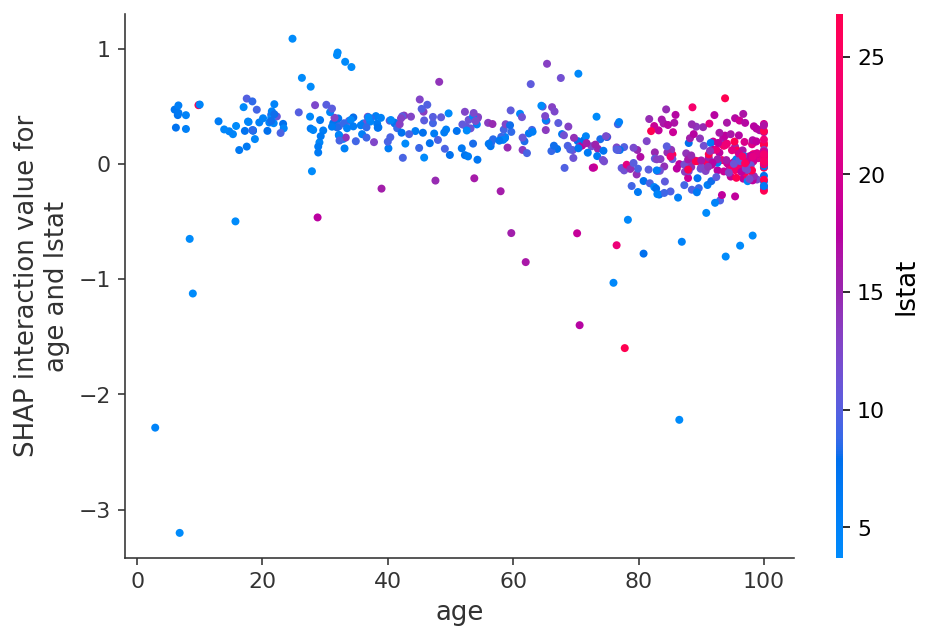

In [266]:
shap.dependence_plot(
    ('age', 'lstat'),
    shap_interact,
    x_boston
)

#### Smart explainer
SHAP also provides a convenience class, [`Explainer`], which is highly recommended. It is able to determine model type itself and select the best explaining algorithm, all automatically.

[`Explainer`]: https://shap-lrjball.readthedocs.io/en/latest/generated/shap.Explainer.html

In [206]:
idx_sample = 7

explainer = shap.Explainer(reg)
shap_value = explainer(x_boston)

shap.force_plot(
    explainer.expected_value,
    shap_value.values[idx_sample],
    features=x_boston.columns
)

### 2.2. Plots

In [ ]:
from dshub import np, pd, metrics, plt, ml
import shap

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
from xgboost import XGBRegressor, XGBClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
shap.initjs()
%config InlineBackend.figure_format = 'retina'

In [3]:
df_boston = pd.read_csv('../data/boston.csv')
x_boston = df_boston.drop(columns='price')
y_boston = df_boston['price']
x_boston.shape

(506, 13)

In [4]:
reg = XGBRegressor()
reg = reg.fit(x_boston, y_boston)

In [5]:
explainer = shap.TreeExplainer(reg)
shap_value = explainer(x_boston)

#### Bar plot
Bar plot is very familiar in model interpretation as it has been widely used to visualize feature importances. In SHAP, the function
[`shap.plots.bar()`] extends the expressivity in many ways:
- *Global* plot aggregates the mean of absolute SHAP values, showing general feature importances.
- *Local* plot displays the real SHAP values of a single observation. For this case only, `shap.plots.waterfall()` can be used as an alternative.
- *Cohort* plot displays global importances for a number of categories.

[`shap.plots.bar()`]: https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html

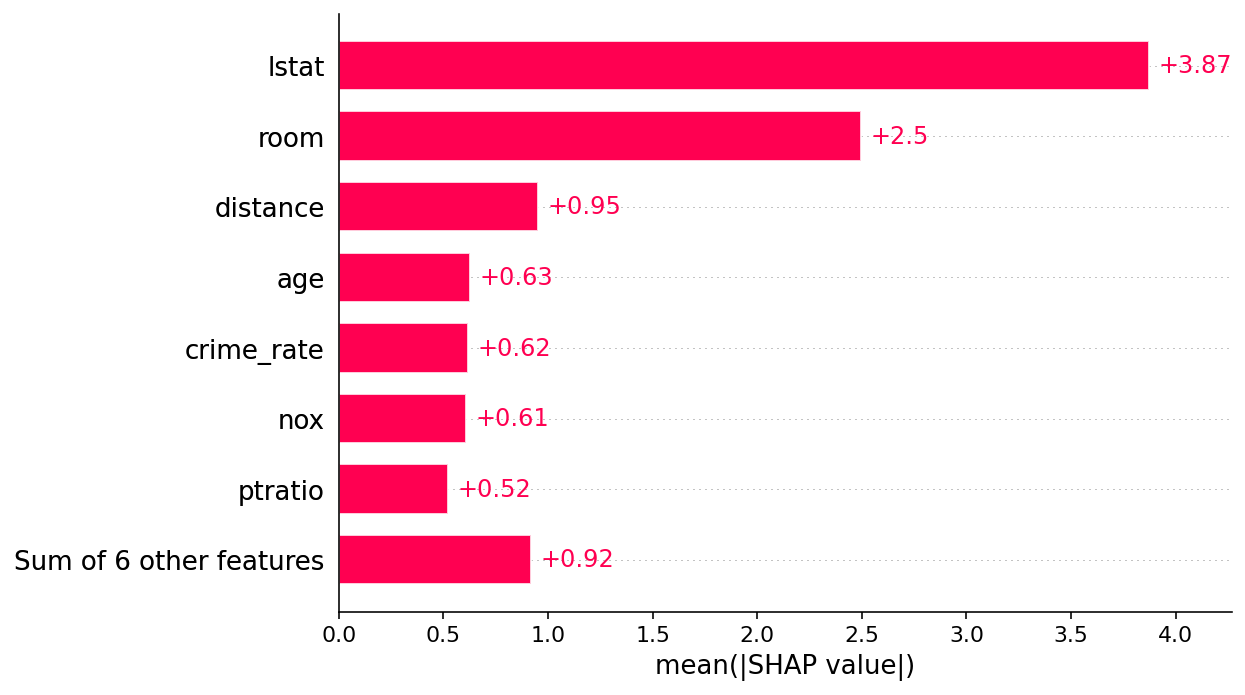

In [12]:
shap.plots.bar(shap_value, max_display=8)

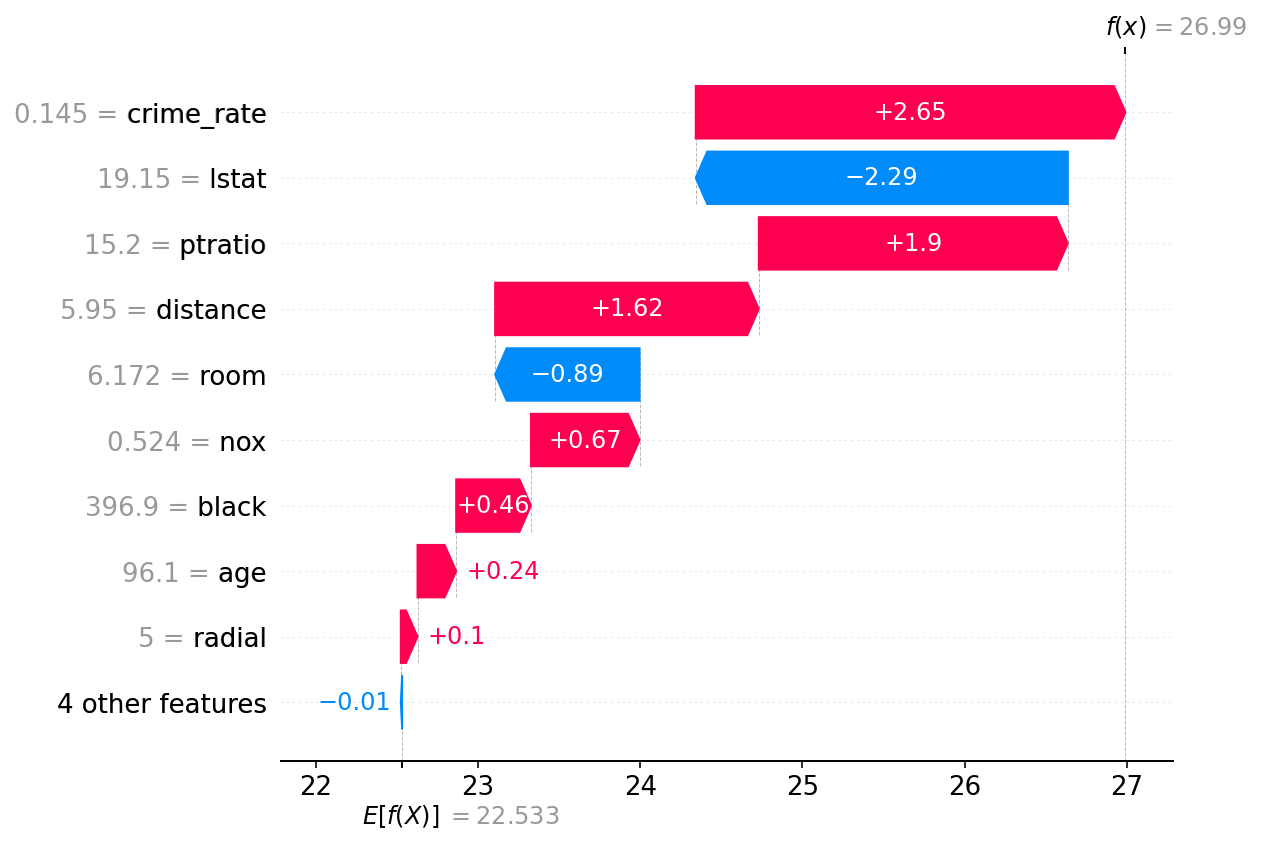

In [17]:
shap.plots.waterfall(shap_value[7])

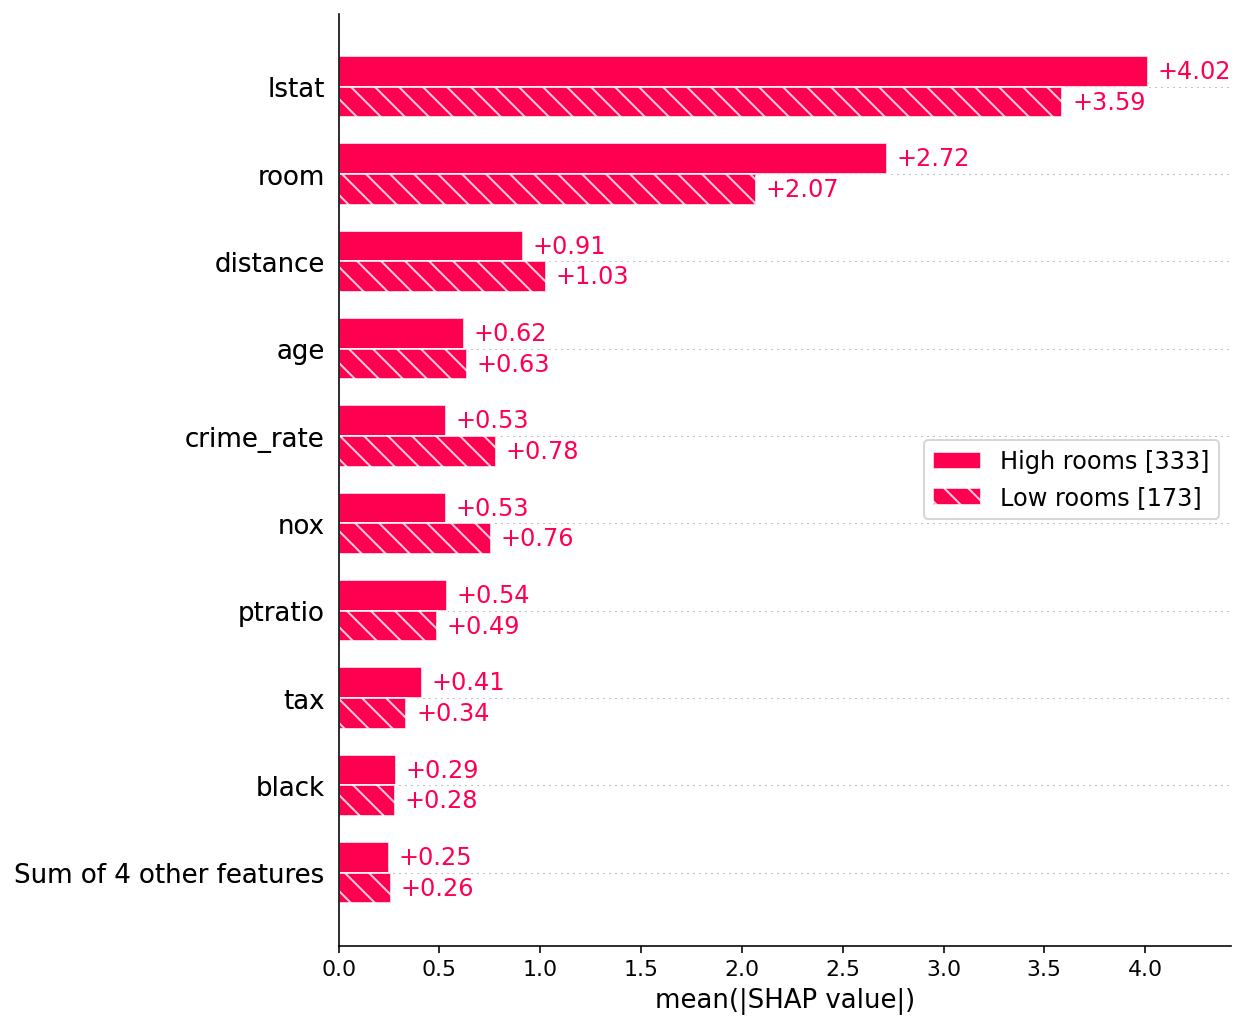

In [14]:
@np.vectorize
def map_room(x):
    if x < 6:
        return 'Low rooms'
    else:
        return 'High rooms'

cohort = map_room(shap_value[:, 'room'].data)
shap.plots.bar(shap_value.cohorts(cohort).abs.mean(0))

#### Beeswarm plot
Beeswarm plot, implemented via the function [`shap.plots.beeswarm()`], visualizes all observations rather than aggregating them like bar plot does. Each dot represents a single cell in the data table, with its color displaying feature value. This tells us in which direction a feature contributes to the model prediction. For example, we can observe that `lstat` contributes decreasingly and `room` contributes *increasingly* to our Boston regression output.

[`shap.plots.beeswarm()`]: https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/beeswarm.html

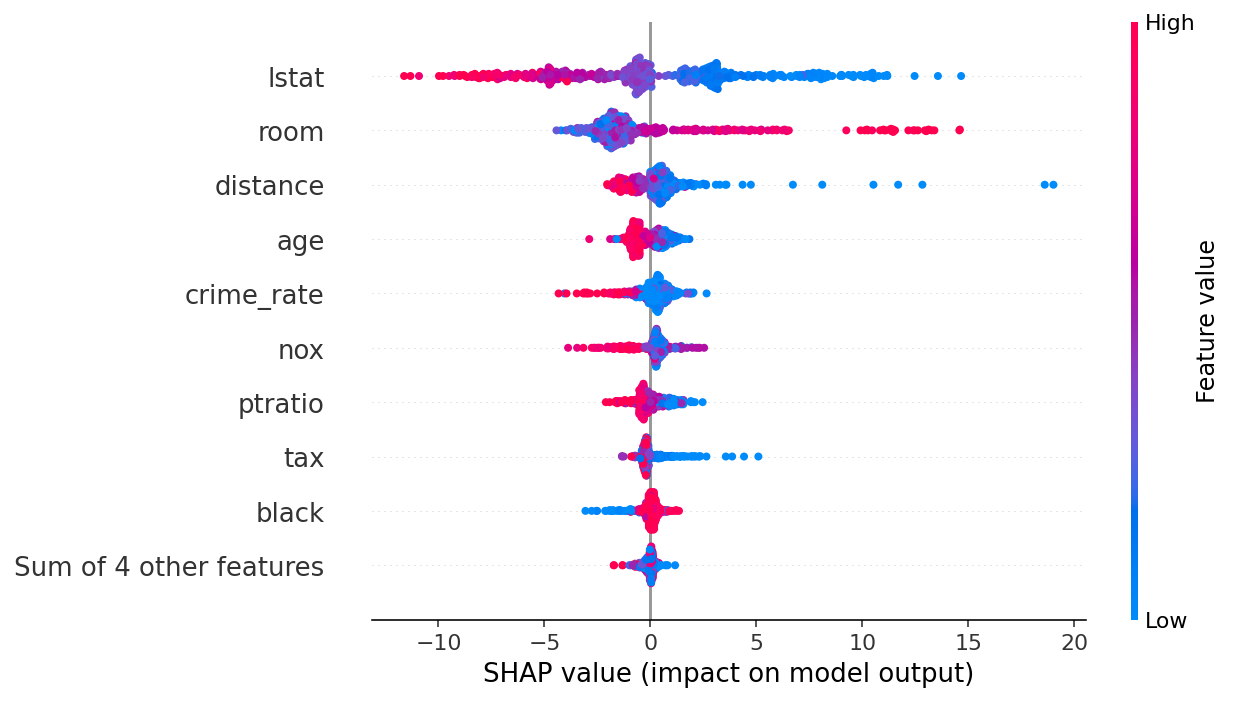

In [19]:
shap.plots.beeswarm(shap_value)

There is another advanced scenario that we can utilize beeswarm plot, which is preprocessing SHAP values before plotting. With some visualization techniques: fixing to a single color and setting opacity to 20%, the chart can now show the distribution of SHAP values. This very useful to double-check the earlier global bar plot if you have any suspection on it. In this case, there is no doubt that
- `lstat` is the most important feature as its SHAP values are uniformally high.
- `room` is the second most important feature, because most of its bees lie at a higher level than other features

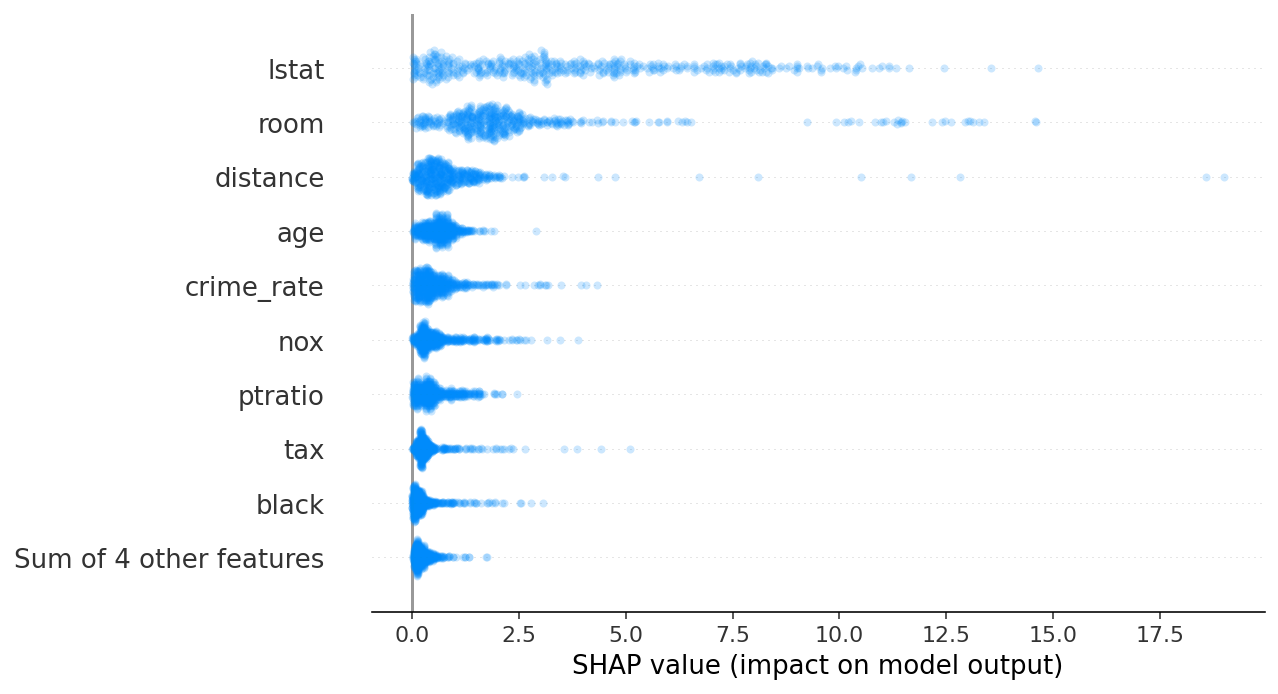

In [7]:
shap.plots.beeswarm(shap_value.abs, color='shap_blue', alpha=0.2)

#### Force plot
The function [`shap.plots.force()`] shows how strong each feature pushes and pulls from the base (expected value) to the final prediction of a sample. When stacking up all predictions, it forms a global plot visualized as a stream graph.

[`shap.plots.force()`]: https://shap.readthedocs.io/en/latest/generated/shap.plots.force.html

In [15]:
shap.plots.force(shap_value[7])

In [14]:
shap.plots.force(shap_value)

#### Decision plot
When there are a lot of features, force plot cannot display them all effectively. With the help of [`shap.plots.decision()`], we have a clearer view of feature impact for specific samples. This plot is constructed bottom-up, starting from the expected model target, then features contribute their SHAP values to this point sequentially. Finished at the top, we have a line for each observation, colored by predicted value. 

[`shap.plots.decision()`]: https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/decision_plot.html

In [47]:
y_boston_pred = reg.predict(x_boston)
error = (y_boston - y_boston_pred).abs()
idxBest = error.argmin()
idxWorst = error.argmax()

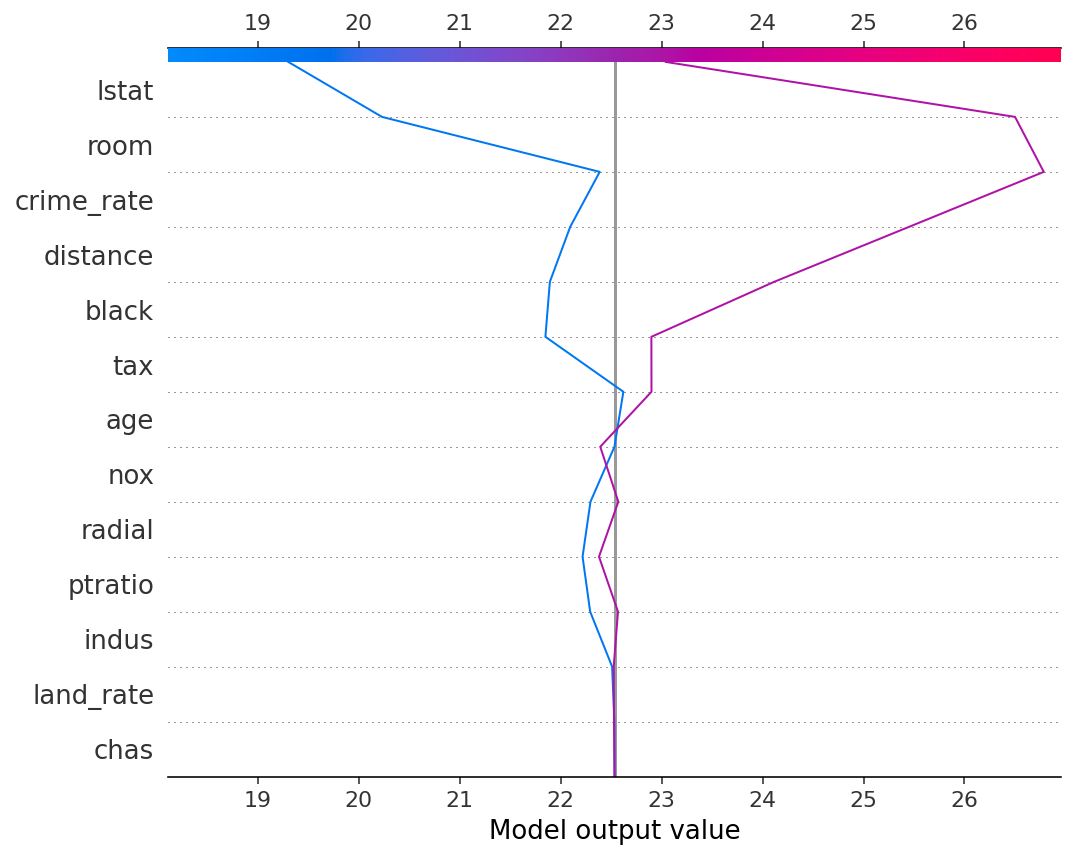

In [49]:
shap.plots.decision(
    explainer.expected_value,
    shap_value.values[[idxBest, idxWorst]],
    x_boston.columns,
)

#### Scatter plot
The function [`shap.plots.scatter()`] plots the correlation between feature values and SHAP values. We can also change dot colors by passing in SHAP values of another feature; if no feature specified, then the feature with the strongest interaction will be infered automatically. In the example below:
- the the same value of `room` can have different impact on the price of different houses, so the relationship is non-linear
- plotting `room` colored by `radial` suggests an interaction between this pair

We can also use [`shap.dependece_plot()`] that requires SHAP interaction values (only available for `TreeExplainer`).

[`shap.plots.scatter()`]: https://shap-lrjball.readthedocs.io/en/latest/example_notebooks/plots/scatter.html
[`shap.dependece_plot()`]: https://shap-lrjball.readthedocs.io/en/latest/example_notebooks/plots/dependence_plot.html

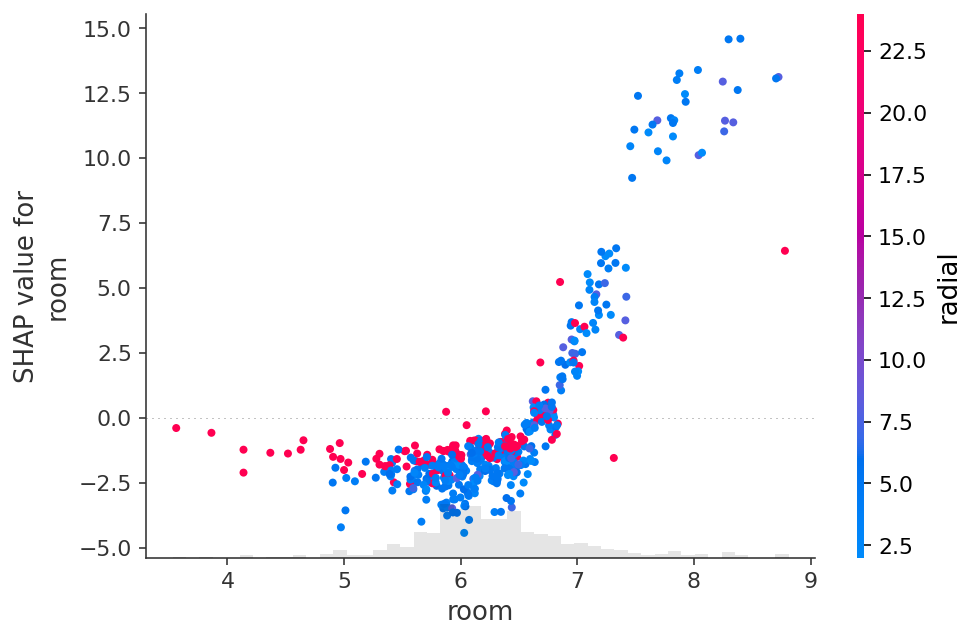

In [13]:
shap.plots.scatter(shap_value[:, 'room'], color=shap_value)

In [69]:
shap_interact = explainer.shap_interaction_values(x_boston)
shap_interact.shape

(506, 13, 13)

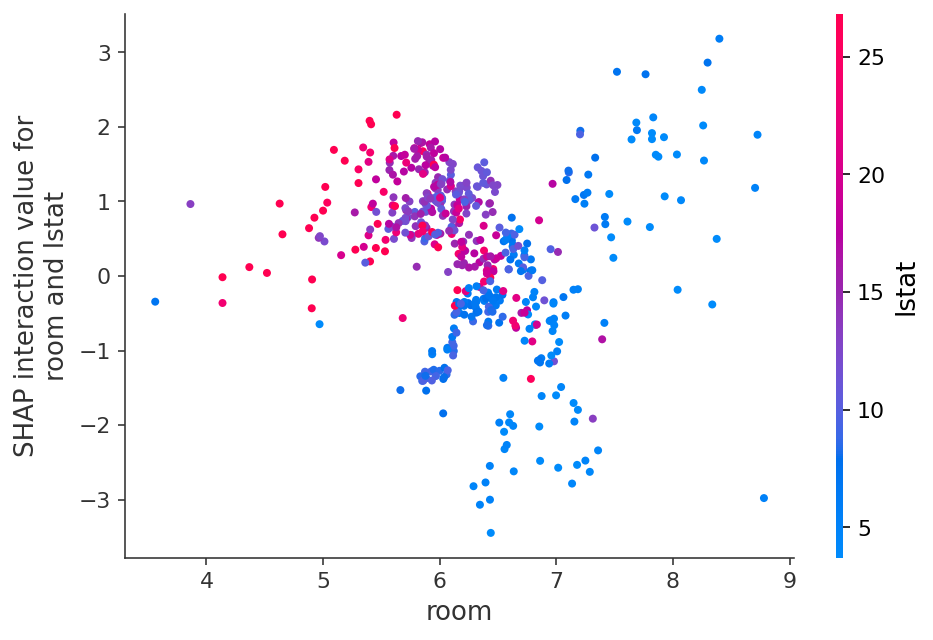

In [71]:
shap.dependence_plot(
    ('room', 'lstat'),
    shap_interact,
    x_boston,
    interaction_index='lstat'
)

## 3. Deep explainers

### 3.1. Text explainers
We can visualize a NLP model using the [`shap.plots.text()`] function. It draws a force plot showing how each word contributes individually to the model output. Useful in tasks such as sentiment analysis (text classification) and translation.

[`shap.plots.text()`]: https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/text.html

In [22]:
import shap
shap.initjs()

import torch
import transformers
import datasets

#### Classification

In [49]:
tokenizer = transformers.AutoTokenizer.from_pretrained("nateraw/bert-base-uncased-emotion", use_fast=True)
model = transformers.AutoModelForSequenceClassification.from_pretrained("nateraw/bert-base-uncased-emotion")
pipe = transformers.pipeline("text-classification", model=model, tokenizer=tokenizer, top_k=1)

In [ ]:
x_emotion = [
    'I feel as confused about life as a teenager or as jaded as a year old man',
    'I have been with petronas for years I feel that petronas has performed well and made a huge profit',
]

explainer = shap.Explainer(pipe)
shap_value = explainer(x_emotion)

In [59]:
shap.plots.text(shap_value[1])

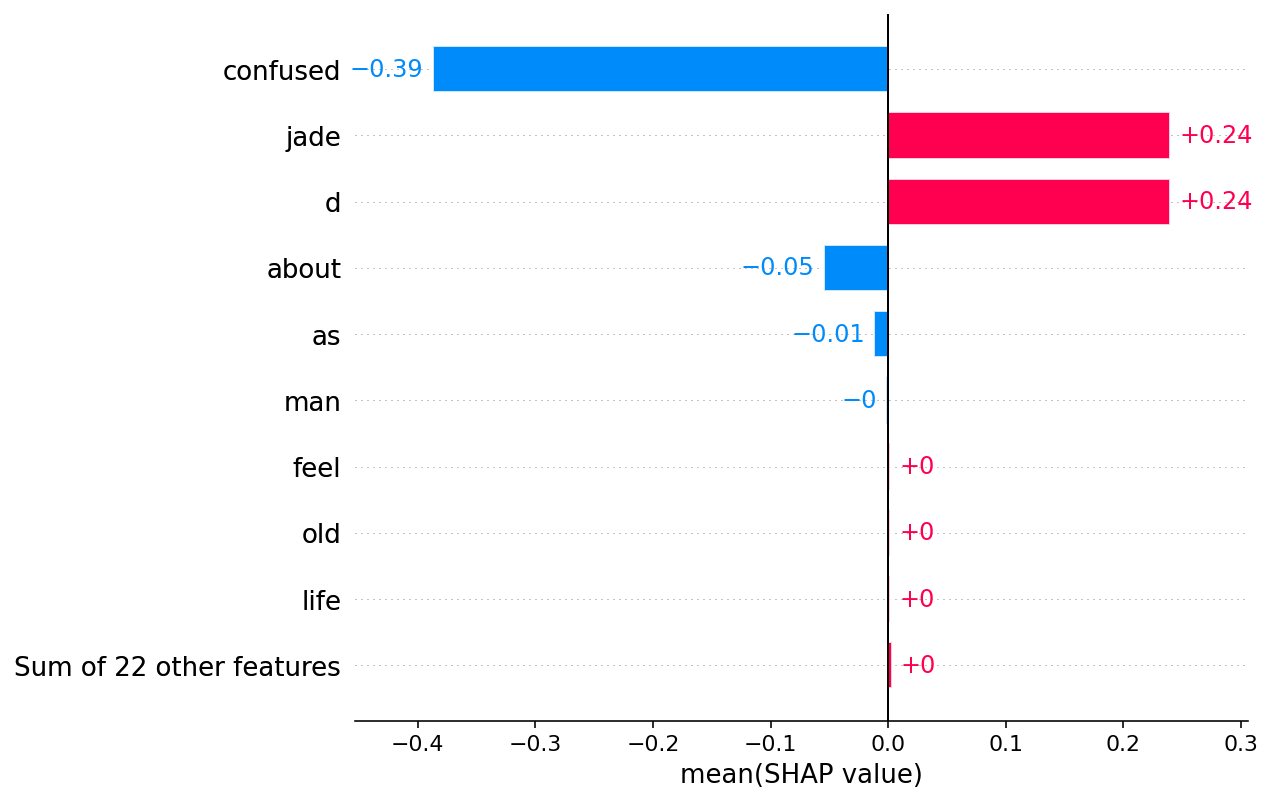

In [60]:
shap.plots.bar(shap_value[:, :, 'sadness'].mean(0))

#### Translation

In [61]:
tokenizer = transformers.AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-vi", use_fast=True)
model = transformers.AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-vi")

In [67]:
x_translate = ["In school, we spent a lot of time playing video game"]

explainer = shap.Explainer(model, tokenizer)
shap_value = explainer(x_translate, fixed_context=1)

In [68]:
shap.plots.text(shap_value)

### 3.2. Image explainers
The function [`shap.plots.image()`] shows how much each pixel contributes to model output.

[`shap.plots.image()`]: https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/image.html

In [ ]:
import dshub

import shap
shap.initjs()

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [6]:
keras.backend.image_data_format()

'channels_last'

In [7]:
height, width, depth = 28, 28, 1
batch_size = 128
n_class = 10

In [8]:
(_, _), (x_mnist, y_mnist) = keras.datasets.mnist.load_data()

x_mnist = x_mnist.reshape(-1, height, width, depth).astype(float)
x_mnist.shape

(10000, 28, 28, 1)

In [9]:
model = keras.Sequential([
    layers.Input((height, width, depth)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(n_class, activation='softmax'),
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.fit(x_mnist, y_mnist, batch_size=128, epochs=10, verbose=0)

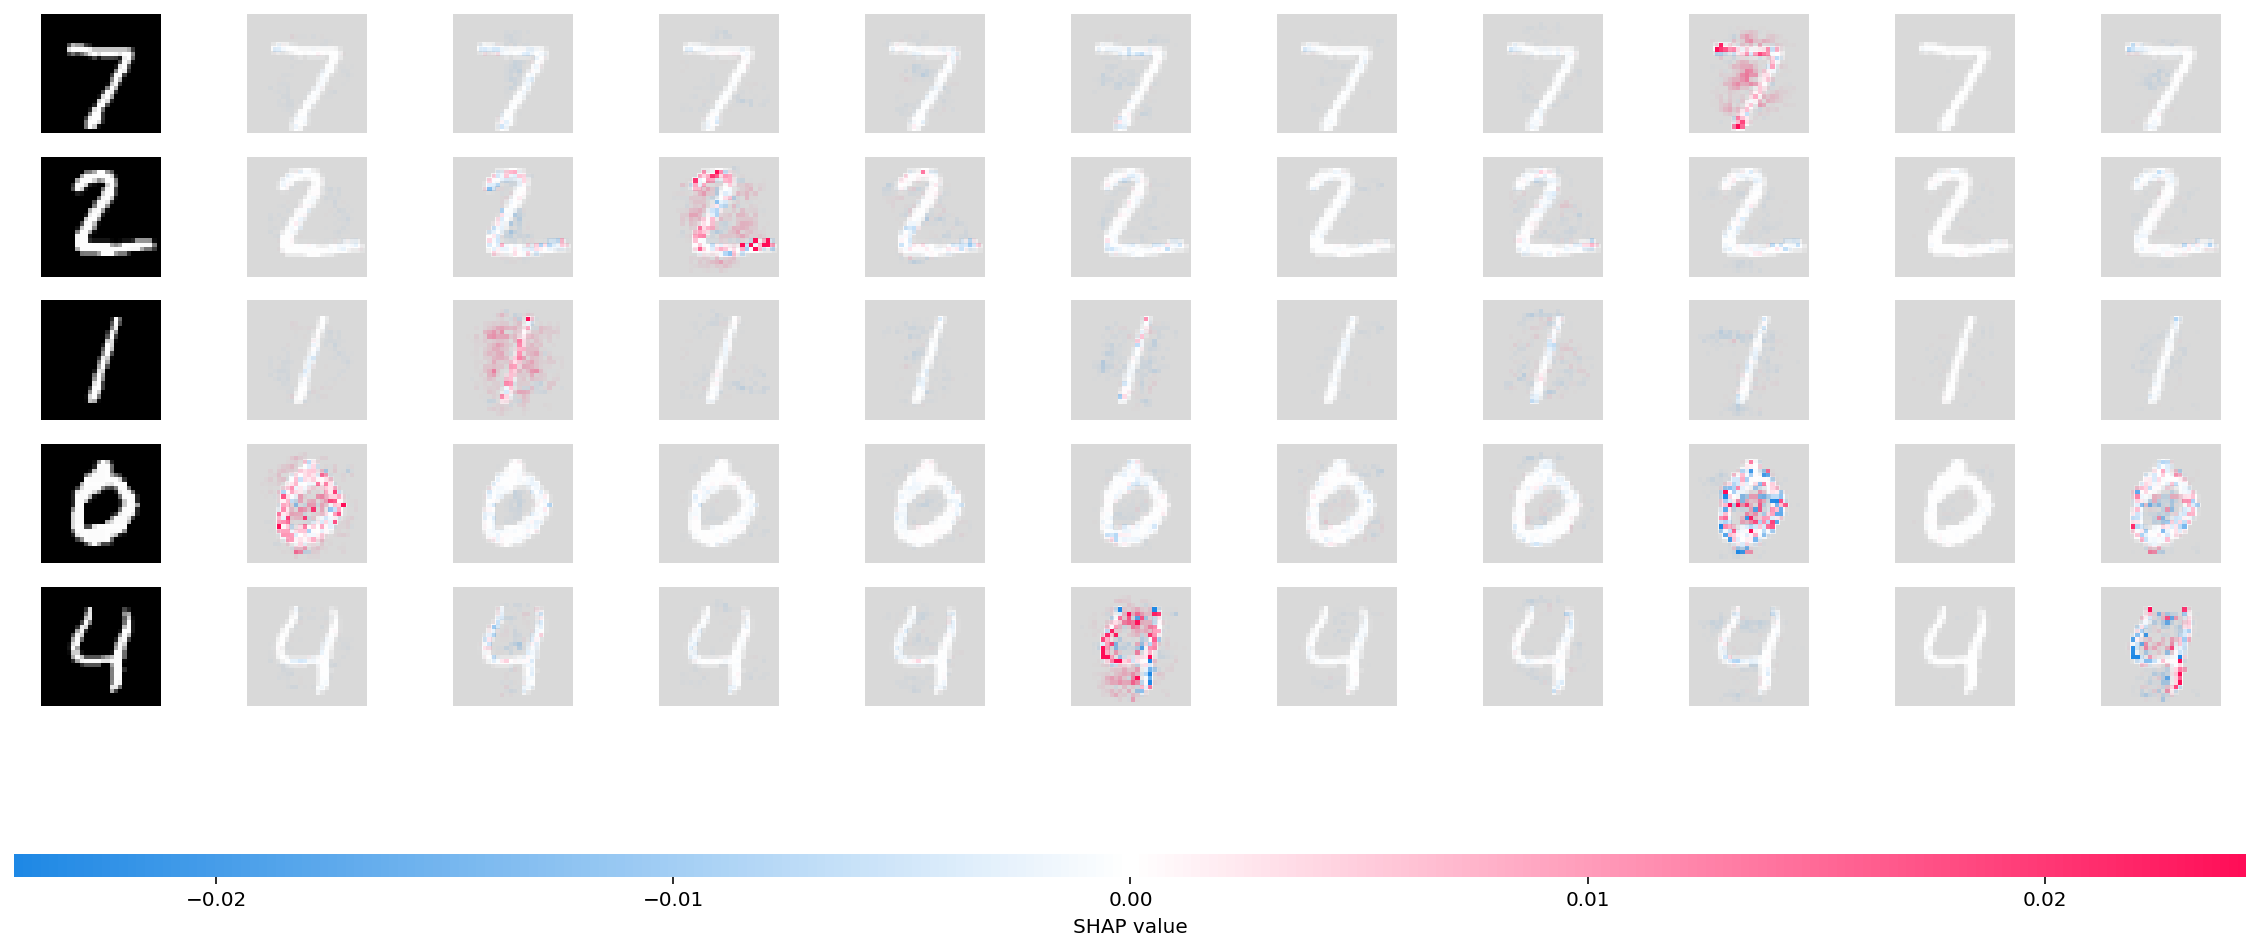

In [12]:
explainer = shap.DeepExplainer(model, data=x_mnist[:100])
shap_value = explainer.shap_values(x_mnist[:5])
shap.plots.image(shap_value, x_mnist[:5])

## Resources
- christophm.github.io - [SHAP](https://christophm.github.io/interpretable-ml-book/shap.html)